# Evaluation Metrics Overview

This notebook aggregates the CHAIR and POPE evaluation metrics stored in `opera_log` and produces publication-style tables and figures to compare decoding strategies across models.

In [1]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titleweight": "bold"})

In [ ]:
def resolve_repo_root() -> Path:
    candidate = Path.cwd()
    if (candidate / "opera_log").exists():
        return candidate
    if (candidate.parent / "opera_log").exists():
        return candidate.parent
    raise FileNotFoundError("Cannot locate opera_log directory from current working directory.")


REPO_ROOT = resolve_repo_root()
CHAIR_ROOT = REPO_ROOT / "opera_log" / "chair_eval_results"
POPE_ROOT = REPO_ROOT / "opera_log" / "pope_eval_results"


def load_chair_metrics(chair_root: Path) -> pd.DataFrame:
    records = []
    for metric_path in chair_root.glob("**/metric.json"):
        parts = metric_path.relative_to(chair_root).parts
        if len(parts) < 3:
            continue
        provider, model, method = parts[:3]
        with metric_path.open() as f:
            data = json.load(f)
        overall = data.get("overall_metrics", {})
        records.append(
            {
                "provider": provider,
                "model": model,
                "method": method,
                **overall,
            }
        )
    df = pd.DataFrame(records)
    metric_cols = ["CHAIRs", "CHAIRi", "Recall", "Len"]
    return (
        df[["provider", "model", "method", *metric_cols]]
        .sort_values(["provider", "model", "method"])
        .reset_index(drop=True)
    )


def load_pope_metrics(pope_root: Path) -> pd.DataFrame:
    type_alias_map = {"adv": "adversarial", "pop": "popular", "rand": "random"}
    records = []
    for metric_path in pope_root.glob("**/*metric.json*"):
        if not metric_path.is_file():
            continue
        parts = metric_path.relative_to(pope_root).parts
        if len(parts) < 4:
            continue
        provider, model, type_alias, method_label = parts[:4]
        if type_alias not in type_alias_map:
            continue
        with metric_path.open() as f:
            data = json.load(f)
        if "-" in method_label:
            base_method, variant_suffix = method_label.split("-", 1)
            variant = variant_suffix
        else:
            base_method = method_label
            variant = "baseline"
        report = data.get("Report", {})
        macro = report.get("macro avg", {})
        weighted = report.get("weighted avg", {})
        records.append(
            {
                "provider": provider,
                "model": model,
                "type_alias": type_alias,
                "pope_type": data.get("POPE_Type", type_alias_map[type_alias]),
                "method": method_label,
                "method_base": data.get("Method", base_method),
                "variant": variant,
                "accuracy": data.get("Accuracy"),
                "f1_macro": macro.get("f1-score"),
                "precision_macro": macro.get("precision"),
                "recall_macro": macro.get("recall"),
                "f1_weighted": weighted.get("f1-score"),
                "precision_weighted": weighted.get("precision"),
                "recall_weighted": weighted.get("recall"),
                "samples": data.get("TotalSamples"),
            }
        )
    sort_cols = ["provider", "model", "variant", "method", "pope_type"]
    return pd.DataFrame(records).sort_values(sort_cols).reset_index(drop=True)


In [3]:
chair_df = load_chair_metrics(CHAIR_ROOT)
pope_df = load_pope_metrics(POPE_ROOT)

print(f"Loaded {len(chair_df)} CHAIR metric entries.")
print(f"Loaded {len(pope_df)} POPE metric entries.")
chair_df.head()


Loaded 22 CHAIR metric entries.
Loaded 53 POPE metric entries.


,provider,model,method,CHAIRs,CHAIRi,Recall,Len
0,Qwen,Qwen2.5-VL-3B-Instruct,10_layers,0.122000,0.049768,0.454664,0.612580
1,Qwen,Qwen2.5-VL-3B-Instruct,10_layers,0.137450,0.061239,0.452304,0.616554
2,Qwen,Qwen2.5-VL-3B-Instruct,beam,0.137725,0.054591,0.447917,0.611517
3,Qwen,Qwen2.5-VL-3B-Instruct,greedy,0.127943,0.054514,0.451118,0.613030
4,google,gemma-3-4b-it,10_layers,0.050881,0.032413,0.342912,0.625793


In [4]:
chair_table = (
    chair_df
    .set_index(["model", "method"])[["CHAIRs", "CHAIRi", "Recall", "Len"]]
    .sort_index()
)

chair_table.style.format("{:.3f}").set_caption(
    "Table 1. CHAIR overall metrics by decoding strategy"
)


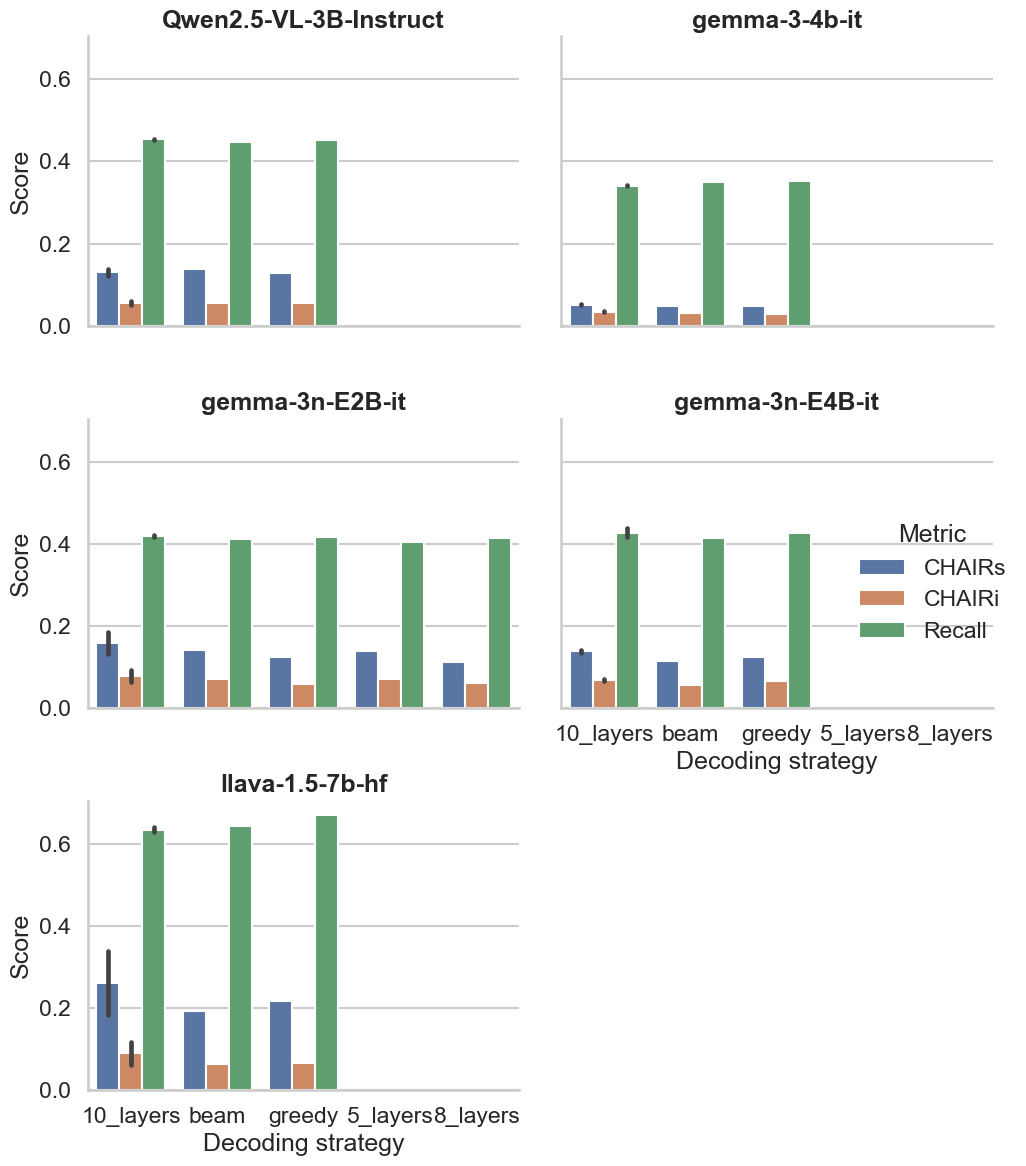

In [5]:
chair_long = chair_df.melt(
    id_vars=["model", "method"],
    value_vars=["CHAIRs", "CHAIRi", "Recall"],
    var_name="metric",
    value_name="score",
)

g = sns.catplot(
    data=chair_long,
    kind="bar",
    x="method",
    y="score",
    hue="metric",
    col="model",
    col_wrap=2,
    height=4,
    aspect=1.1,
)
g.set_axis_labels("Decoding strategy", "Score")
g.set_titles("{col_name}")
if g._legend is not None:
    g._legend.set_title("Metric")
plt.tight_layout()
plt.show()


In [6]:
pope_table = (
    pope_df
    .pivot_table(
        index=["model", "variant", "pope_type"],
        columns="method",
        values="f1_weighted",
    )
    .sort_index()
)

pope_table.style.format("{:.3f}").set_caption(
    "Table 2. POPE weighted F1 by decoding strategy and evaluation type"
)


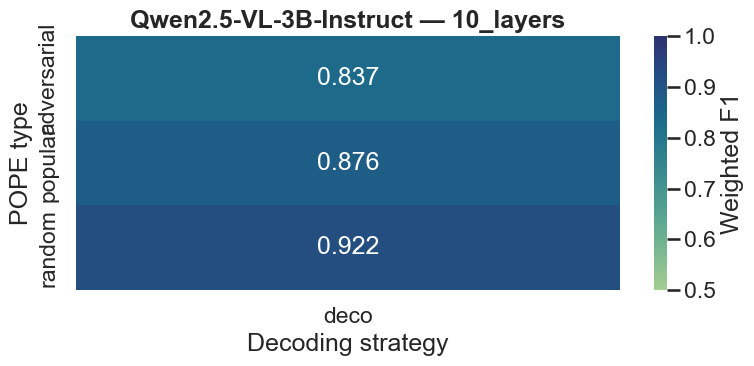

ValueError: Index contains duplicate entries, cannot reshape

In [7]:
for (model, variant), subset in pope_df.groupby(["model", "variant"]):
    pivot = subset.pivot(index="pope_type", columns="method", values="f1_weighted")
    pivot = pivot.loc[sorted(pivot.index)]
    pivot = pivot[sorted(pivot.columns)]
    plt.figure(figsize=(8, 4))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="crest",
        vmin=0.5,
        vmax=1.0,
        cbar_kws={"label": "Weighted F1"},
    )
    plt.title(f"{model} — {variant}")
    plt.xlabel("Decoding strategy")
    plt.ylabel("POPE type")
    plt.tight_layout()
    plt.show()
